In [1]:
import subprocess
result = subprocess.run(
    ["pip3", "install", "camel-tools"],
    capture_output=True,
    text=True
)
print("Done!")

# Test import
try:
    from camel_tools.ner import NERecognizer
    print("✓ CAMeL Tools NER available!")
except Exception as e:
    print(f"NER import issue: {e}")

try:
    from camel_tools.tokenizers.word import simple_word_tokenize
    print("✓ CAMeL Tools tokenizer available!")
except Exception as e:
    print(f"Tokenizer issue: {e}")

Done!


/Users/juhi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


✓ CAMeL Tools NER available!
✓ CAMeL Tools tokenizer available!


In [2]:
import json
import os

with open("data/cleaned_text/all_cleaned.json",
          encoding="utf-8") as f:
    cleaned_docs = json.load(f)

print("✓ Loaded cleaned documents")
for name, data in cleaned_docs.items():
    print(f"  {name}: {data['clean_chars']} chars")

✓ Loaded cleaned documents
  arabic_doc_001.jpg: 1057 chars
  arabic_doc_004.jpg: 578 chars
  arabic_doc_005.jpg: 450 chars


## Simple Rule-Based NER

In [3]:
import re

# Common Arabic name prefixes and titles
PERSON_TITLES = [
    'الشيخ', 'الدكتور', 'السيد', 'الأستاذ',
    'بن', 'ابن', 'أبو', 'عبد'
]

# Common Egyptian and Giza place names
PLACE_NAMES = [
    'القاهرة', 'الجيزة', 'الإسكندرية', 'مصر',
    'الهرم', 'الأهرام', 'المقبرة', 'الصحراء',
    'النيل', 'سيناء', 'الأقصر', 'أسوان',
    'شبوة', 'اليمنية', 'البمنية'
]

# Date indicators
DATE_WORDS = [
    'التاريخ', 'يوم', 'شهر', 'سنة', 'عام',
    'الاثنين', 'الثلاثاء', 'الأربعاء', 'الخميس',
    'الجمعة', 'السبت', 'الأحد',
    'رمضان', 'محرم', 'صفر', 'ربيع', 'جمادى',
    'رجب', 'شعبان', 'شوال', 'ذو'
]

# Archaeological object words
OBJECT_WORDS = [
    'تمثال', 'حجر', 'مقبرة', 'اثر', 'آثار',
    'لوحة', 'كتابة', 'نقش', 'ورقة', 'مخطوط',
    'فخار', 'عملة', 'خاتم', 'تابوت', 'مومياء'
]

def extract_entities_rule_based(text):
    """
    Extract named entities using rule-based approach
    Works on noisy OCR Arabic text
    """
    entities = {
        "PERSON": [],
        "PLACE": [],
        "DATE": [],
        "OBJECT": [],
        "ORG": []
    }
    
    words = text.split()
    
    for i, word in enumerate(words):
        # Clean word
        clean_word = re.sub(r'[^\u0600-\u06FF]', '', word)
        
        if not clean_word:
            continue
        
        # Check for person indicators
        if clean_word in PERSON_TITLES:
            # Get next word as name
            if i + 1 < len(words):
                next_word = re.sub(
                    r'[^\u0600-\u06FF]', '', words[i+1])
                if next_word and len(next_word) > 2:
                    entity = f"{clean_word} {next_word}"
                    if entity not in entities["PERSON"]:
                        entities["PERSON"].append(entity)
        
        # Check for place names
        if clean_word in PLACE_NAMES:
            if clean_word not in entities["PLACE"]:
                entities["PLACE"].append(clean_word)
        
        # Check for date words
        if clean_word in DATE_WORDS:
            # Get surrounding context
            start = max(0, i-1)
            end = min(len(words), i+3)
            context = ' '.join(words[start:end])
            context = re.sub(r'[^\u0600-\u06FF\s]', '', context)
            if context.strip() and context not in entities["DATE"]:
                entities["DATE"].append(context.strip())
        
        # Check for objects
        if clean_word in OBJECT_WORDS:
            # Get surrounding context
            start = max(0, i-1)
            end = min(len(words), i+2)
            context = ' '.join(words[start:end])
            context = re.sub(r'[^\u0600-\u06FF\s]', '', context)
            if context.strip() and context not in entities["OBJECT"]:
                entities["OBJECT"].append(context.strip())
        
        # Check for organizations
        if 'الجمهورية' in clean_word or 'محافظة' in clean_word:
            start = max(0, i)
            end = min(len(words), i+3)
            context = ' '.join(words[start:end])
            context = re.sub(r'[^\u0600-\u06FF\s]', '', context)
            if context.strip() and context not in entities["ORG"]:
                entities["ORG"].append(context.strip())
    
    return entities

print("✓ Rule-based NER functions defined!")

✓ Rule-based NER functions defined!


In [4]:
import json
import os

os.makedirs("data/entities", exist_ok=True)

all_entities = {}

for doc_name, doc_data in cleaned_docs.items():
    print(f"\n{'='*50}")
    print(f"Extracting entities from: {doc_name}")
    
    text = doc_data['cleaned_text']
    entities = extract_entities_rule_based(text)
    
    all_entities[doc_name] = {
        "description": doc_data['description'],
        "entities": entities,
        "total_entities": sum(len(v) for v in entities.values())
    }
    
    print(f"\nENTITIES FOUND:")
    for entity_type, entity_list in entities.items():
        if entity_list:
            print(f"\n  {entity_type}:")
            for e in entity_list:
                print(f"    → {e}")
    
    print(f"\nTotal entities: {all_entities[doc_name]['total_entities']}")

# Save entities
with open("data/entities/all_entities.json", "w",
          encoding="utf-8") as f:
    json.dump(all_entities, f, ensure_ascii=False, indent=2)

print(f"\n✓ All entities saved!")


Extracting entities from: arabic_doc_001.jpg

ENTITIES FOUND:

  PERSON:
    → بن فوا

Total entities: 1

Extracting entities from: arabic_doc_004.jpg

ENTITIES FOUND:

  PERSON:
    → بن ماش
    → بن ميلك

  PLACE:
    → البمنية

  ORG:
    → محافظة شهرة الارثقات

Total entities: 4

Extracting entities from: arabic_doc_005.jpg

ENTITIES FOUND:

Total entities: 0

✓ All entities saved!


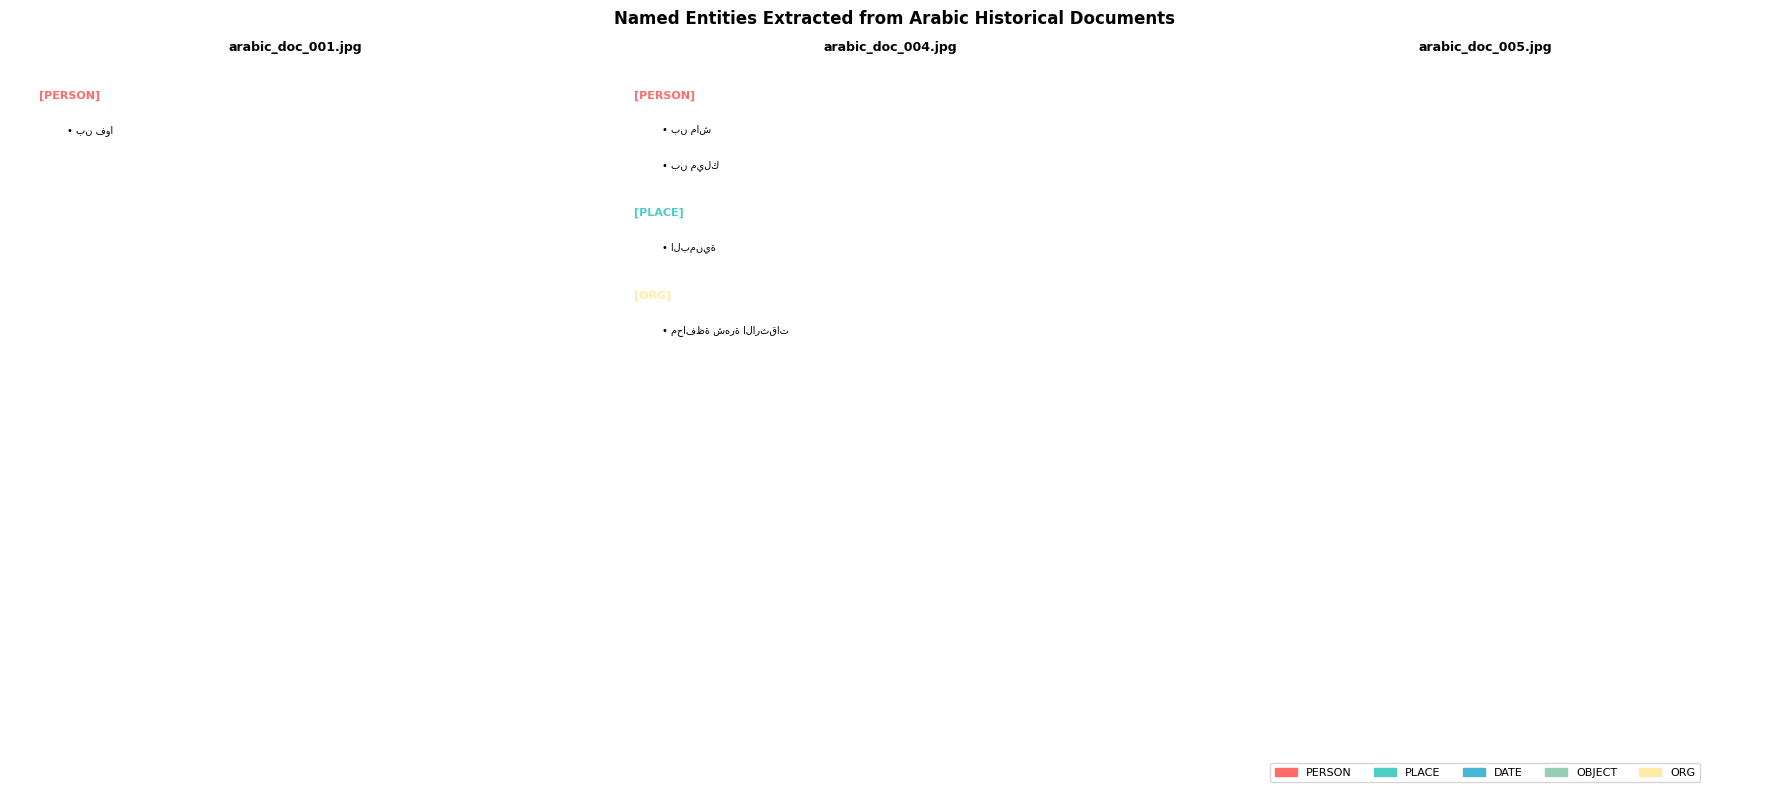

✓ Visualization saved!


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

colors = {
    "PERSON": "#FF6B6B",
    "PLACE": "#4ECDC4", 
    "DATE": "#45B7D1",
    "OBJECT": "#96CEB4",
    "ORG": "#FFEAA7"
}

for idx, (doc_name, doc_data) in enumerate(all_entities.items()):
    ax = axes[idx]
    entities = doc_data['entities']
    
    y_pos = 0.95
    ax.text(0.5, 1.02, doc_name[:20], 
            transform=ax.transAxes,
            ha='center', fontsize=9, fontweight='bold')
    
    for etype, elist in entities.items():
        if elist:
            color = colors.get(etype, '#DDD')
            ax.text(0.05, y_pos, f"[{etype}]",
                   transform=ax.transAxes,
                   fontsize=8, color=color,
                   fontweight='bold')
            y_pos -= 0.05
            
            for entity in elist[:5]:
                ax.text(0.1, y_pos, f"• {entity}",
                       transform=ax.transAxes,
                       fontsize=7)
                y_pos -= 0.05
            
            y_pos -= 0.02
    
    ax.axis('off')
    ax.set_facecolor('#f8f8f8')

# Legend
patches = [mpatches.Patch(color=c, label=t) 
           for t, c in colors.items()]
plt.legend(handles=patches, loc='lower center',
           bbox_to_anchor=(0.5, -0.05),
           ncol=5, fontsize=8)

plt.suptitle('Named Entities Extracted from Arabic Historical Documents',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("data/entities/entity_visualization.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualization saved!")

## Use CAMeL Tools NER Model

In [7]:
from camel_tools.ner import NERecognizer

print("Loading CAMeL Tools NER model...")
ner = NERecognizer.pretrained()  # uses 'arabert' by default
print("✓ NER model loaded!")

Loading CAMeL Tools NER model...


Some weights of the model checkpoint at /Users/juhi/.camel_tools/data/ner/arabert were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


✓ NER model loaded!


In [8]:
from camel_tools.tokenizers.word import simple_word_tokenize

def extract_entities_camel(text, ner_model):
    entities = {
        "PERSON": [],
        "LOCATION": [],
        "ORGANIZATION": [],
        "MISC": []
    }
    
    try:
        tokens = simple_word_tokenize(text)
        if not tokens:
            return entities
            
        labels = ner_model.predict_sentence(tokens)
        
        current_entity = []
        current_type = None
        
        for token, label in zip(tokens, labels):
            if label.startswith('B-'):
                if current_entity and current_type:
                    entity_text = ' '.join(current_entity)
                    if entity_text not in entities.get(current_type, []):
                        entities.setdefault(current_type, []).append(entity_text)
                current_type = label[2:]
                current_entity = [token]
                
            elif label.startswith('I-') and current_entity:
                current_entity.append(token)
                
            else:
                if current_entity and current_type:
                    entity_text = ' '.join(current_entity)
                    if entity_text not in entities.get(current_type, []):
                        entities.setdefault(current_type, []).append(entity_text)
                current_entity = []
                current_type = None
        
        if current_entity and current_type:
            entity_text = ' '.join(current_entity)
            entities.setdefault(current_type, []).append(entity_text)
            
    except Exception as e:
        print(f"  Error: {e}")
    
    return entities

# Run on all documents
camel_entities = {}

for doc_name, doc_data in cleaned_docs.items():
    print(f"\n{'='*50}")
    print(f"CAMeL NER on: {doc_name}")
    
    text = doc_data['cleaned_text']
    entities = extract_entities_camel(text, ner)
    
    camel_entities[doc_name] = {
        "description": doc_data['description'],
        "entities": entities,
        "total": sum(len(v) for v in entities.values())
    }
    
    print(f"Total entities found: {camel_entities[doc_name]['total']}")
    for etype, elist in entities.items():
        if elist:
            print(f"\n  {etype}:")
            for e in elist:
                print(f"    → {e}")

with open("data/entities/camel_entities.json", "w",
          encoding="utf-8") as f:
    json.dump(camel_entities, f, ensure_ascii=False, indent=2)

print("\n✓ CAMeL NER results saved!")


CAMeL NER on: arabic_doc_001.jpg
Total entities found: 8

  MISC:
    → سيو

  LOC:
    → ستعسين
    → ااا ادس
    → سناغا
    → ارلا
    → لسمياق

  PERS:
    → ايهالقا بو

  ORG:
    → ايناد

CAMeL NER on: arabic_doc_004.jpg
Total entities found: 7

  PERS:
    → معدو
    → يي
    → ايريصي سين
    → سوك بن ماش
    → ريمت بن
    → معن بن ميلك

  ORG:
    → مم

CAMeL NER on: arabic_doc_005.jpg
Total entities found: 16

  LOC:
    → اباصاحة
    → بقن خزراذالويزبزج
    → والناط
    → القنظوض
    → ركان
    → بت
    → عاراذ
    → ابرزباف

  ORG:
    → ابالرسا
    → غورنالتنطزعل
    → والشتازتدود
    → الودج
    → الاو زيرف
    → اشنا
    → نادي مال
    → لمر ريجياه

✓ CAMeL NER results saved!


In [9]:
combined_entities = {}

for doc_name in cleaned_docs.keys():
    rule_ents = all_entities[doc_name]['entities']
    camel_ents = camel_entities[doc_name]['entities']
    
    combined = {}
    all_types = set(list(rule_ents.keys()) + list(camel_ents.keys()))
    
    for etype in all_types:
        rule_list = rule_ents.get(etype, [])
        camel_list = camel_ents.get(etype, [])
        merged = list(set(rule_list + camel_list))
        if merged:
            combined[etype] = merged
    
    combined_entities[doc_name] = {
        "description": cleaned_docs[doc_name]['description'],
        "entities": combined,
        "total": sum(len(v) for v in combined.values())
    }
    
    print(f"\n{doc_name}:")
    print(f"  Rule-based: {sum(len(v) for v in rule_ents.values())}")
    print(f"  CAMeL NER:  {sum(len(v) for v in camel_ents.values())}")
    print(f"  Combined:   {combined_entities[doc_name]['total']}")
    
    print(f"  Entities:")
    for etype, elist in combined.items():
        if elist:
            print(f"    {etype}: {elist}")

with open("data/entities/combined_entities.json", "w",
          encoding="utf-8") as f:
    json.dump(combined_entities, f, 
              ensure_ascii=False, indent=2)

print("\n✓ Combined entities saved!")


arabic_doc_001.jpg:
  Rule-based: 1
  CAMeL NER:  8
  Combined:   9
  Entities:
    LOC: ['لسمياق', 'ااا ادس', 'ستعسين', 'سناغا', 'ارلا']
    PERS: ['ايهالقا بو']
    ORG: ['ايناد']
    MISC: ['سيو']
    PERSON: ['بن فوا']

arabic_doc_004.jpg:
  Rule-based: 4
  CAMeL NER:  7
  Combined:   11
  Entities:
    PERS: ['يي', 'ريمت بن', 'معدو', 'سوك بن ماش', 'ايريصي سين', 'معن بن ميلك']
    ORG: ['محافظة شهرة الارثقات', 'مم']
    PERSON: ['بن ميلك', 'بن ماش']
    PLACE: ['البمنية']

arabic_doc_005.jpg:
  Rule-based: 0
  CAMeL NER:  16
  Combined:   16
  Entities:
    LOC: ['والناط', 'عاراذ', 'اباصاحة', 'بقن خزراذالويزبزج', 'ابرزباف', 'بت', 'القنظوض', 'ركان']
    ORG: ['غورنالتنطزعل', 'الاو زيرف', 'نادي مال', 'لمر ريجياه', 'اشنا', 'والشتازتدود', 'ابالرسا', 'الودج']

✓ Combined entities saved!
